# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **631 images**, equally divided into two categories:

- **With Helmet:** 311 images showing workers wearing helmets.
- **Without Helmet:** 320 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [1]:
!pip install tensorflow[and-cuda] numpy==1.25.2 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 51.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [2]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.20.0


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [3]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it will affect the overall performance, so be mindful of that.
tf.config.experimental.enable_op_determinism()

# **Data Overview**


##Loading the data

In [6]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Images shape: (631, 200, 200, 3)
Labels shape: (631, 1)


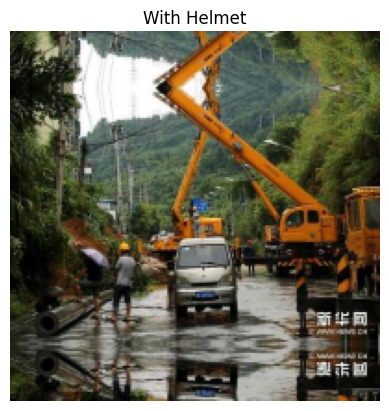

In [7]:
# Load the image file of the dataset
images = np.load('/content/drive/My Drive/Data Science Course/Introduction to Computer Vision/Assignment/images_proj.npy')

# Load the labels file of the dataset
labels = pd.read_csv('/content/drive/My Drive/Data Science Course/Introduction to Computer Vision/Assignment/Labels_proj.csv')

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

# Mapping the numeric labels to human-readable class names
# 0 -> Without Helmet, 1 -> With Helmet
label_names = {0: 'Without Helmet', 1: 'With Helmet'}

# OpenCV loads images in BGR order; converting to RGB for correct visualization
for i in range(len(images)):
    images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

plt.imshow(images[0])
plt.title(label_names[labels['Label'][0]])
plt.axis('off')
plt.show()

# **Exploratory Data Analysis**

###Plot random images from each of the classes and print their corresponding labels.

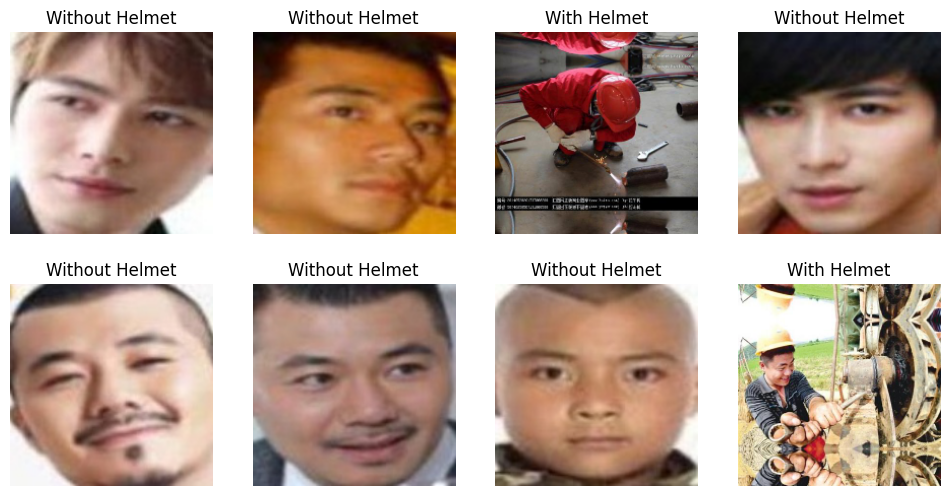

In [8]:
def plot_images(images, labels):
    keys = dict(labels['Label'])                      # index -> label value
    rows, cols = 2, 4
    fig = plt.figure(figsize=(12, 6))
    for i in range(rows * cols):
        random_index = np.random.randint(0, len(labels))
        ax = fig.add_subplot(rows, cols, i + 1)
        ax.imshow(images[random_index])
        ax.set_title(label_names[keys[random_index]])
        ax.axis('off')
    plt.show()

plot_images(images, labels)

## Checking for class imbalance


Label
0    320
1    311
Name: count, dtype: int64


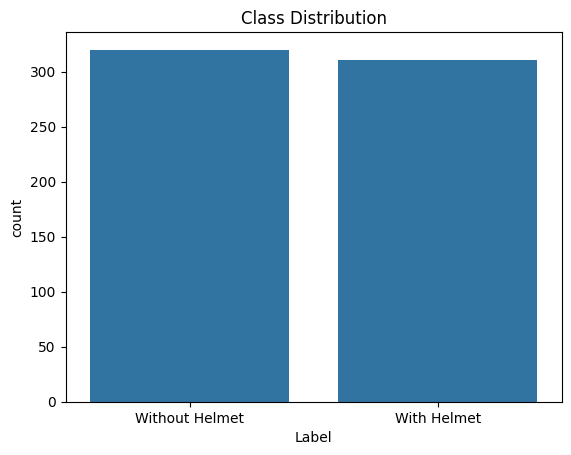

In [9]:
# Checking the distribution of the two classes
print(labels['Label'].value_counts())

sns.countplot(x=labels['Label'])
plt.xticks([0, 1], ['Without Helmet', 'With Helmet'])
plt.title('Class Distribution')
plt.show()

# **Data Preprocessing**

## Converting images to grayscale

Grayscale (3-channel) images shape: (631, 200, 200, 3)


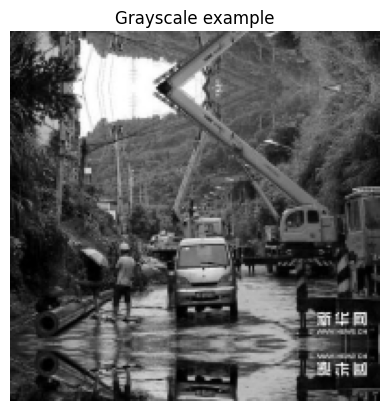

In [10]:
# Converting the images to grayscale to reduce the dependence on colour information.
# The pretrained VGG-16 network expects a 3-channel input, so after converting to a
# single grayscale channel we stack it back into 3 identical channels. This keeps a
# single, consistent input pipeline for both the custom CNN and the VGG-16 models.
images_gray = []
for i in range(len(images)):
    gray = cv2.cvtColor(images[i], cv2.COLOR_RGB2GRAY)        # (H, W) single channel
    gray_3ch = np.stack([gray, gray, gray], axis=-1)         # (H, W, 3)
    images_gray.append(gray_3ch)

images_gray = np.array(images_gray)
print("Grayscale (3-channel) images shape:", images_gray.shape)

plt.imshow(images_gray[0])
plt.title('Grayscale example')
plt.axis('off')
plt.show()

### Splitting the dataset



In [11]:
# First split off 20% as a temporary set, then split that equally into validation and test.
# Stratifying on the label preserves the class balance across every split.
X_train, X_temp, y_train, y_temp = train_test_split(
    images_gray, labels, test_size=0.2, random_state=42, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(504, 200, 200, 3) (504, 1)
(63, 200, 200, 3) (63, 1)
(64, 200, 200, 3) (64, 1)


### Data Normalization

In [12]:
# Scaling the pixel values from [0, 255] to [0, 1]
X_train_normalized = X_train.astype('float32') / 255.0
X_val_normalized = X_val.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

# Numpy versions of the targets for ImageDataGenerator.flow() / model.fit().
# The DataFrame versions (y_train, y_val, y_test) are kept for the metric utilities above,
# which call target.to_numpy() internally.
y_train_arr = y_train.to_numpy()
y_val_arr = y_val.to_numpy()
y_test_arr = y_test.to_numpy()

# Common training settings
batch_size = 32
epochs = 20

# Helper to visualize a few validation predictions for a given model
def visualize_predictions(model, indices=[0, 5, 10]):
    for idx in indices:
        plt.figure(figsize=(2, 2))
        plt.imshow(X_val[idx])
        plt.axis('off')
        plt.show()
        prob = model.predict(X_val_normalized[idx].reshape(1, 200, 200, 3))[0][0]
        pred = int(prob > 0.5)
        print('Predicted Label:', label_names[pred], '(prob=%.2f)' % prob)
        print('True Label     :', label_names[int(y_val.iloc[idx]['Label'])])
        print('-' * 30)

# **Model Building**

##Model Evaluation Criterion

## Utility Functions

In [13]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [14]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

##Model 1: Simple Convolutional Neural Network (CNN)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 200, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,120,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,214,273 (19.89 MB)

 Trainable params: 5,213,825 (19.89 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - accuracy: 0.9385 - loss: 1.1702 - val_accuracy: 0.5079 - val_loss: 38.9564
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.9722 - loss: 1.5094 - val_accuracy: 0.5079 - val_loss: 54.9422
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9802 - loss: 0.2126 - val_accuracy: 0.5079 - val_loss: 64.6424
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.9901 - loss: 0.0263 - val_accuracy: 0.5079 - val_loss: 78.4777
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.9960 - loss: 0.0208 - val_accuracy: 0.5079 - val_loss: 90.0858
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.5079 - val_loss: 89.0441
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.9901 - loss: 0.1681 - val_accuracy: 0.5079 - val_loss: 79.3725
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.9940 - loss: 0.1436 - val_accur

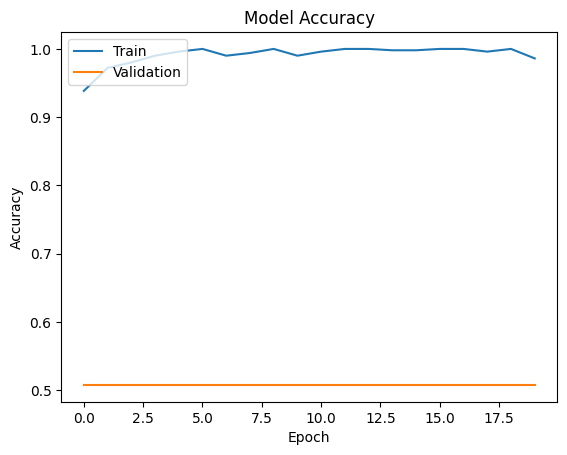

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.507937  0.507937   0.257999  0.342189
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


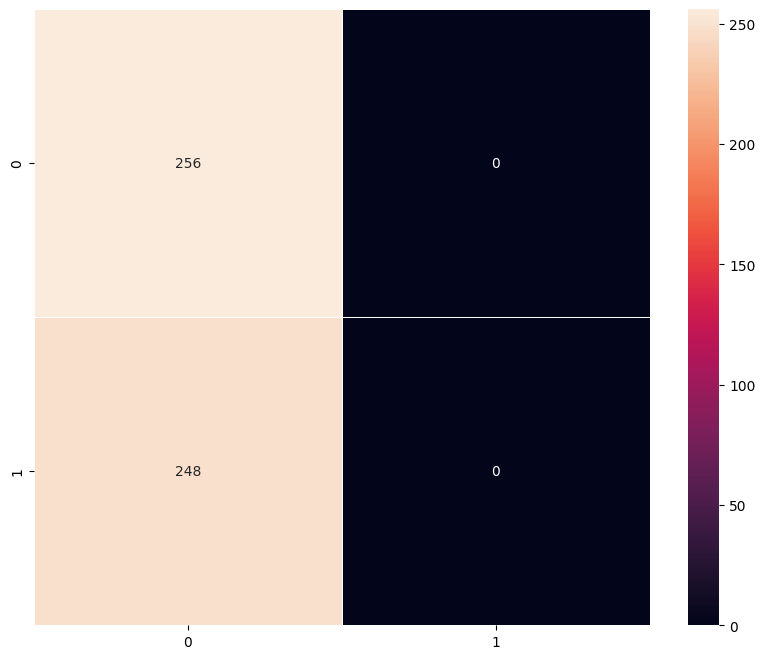

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.507937  0.507937   0.257999  0.342189
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


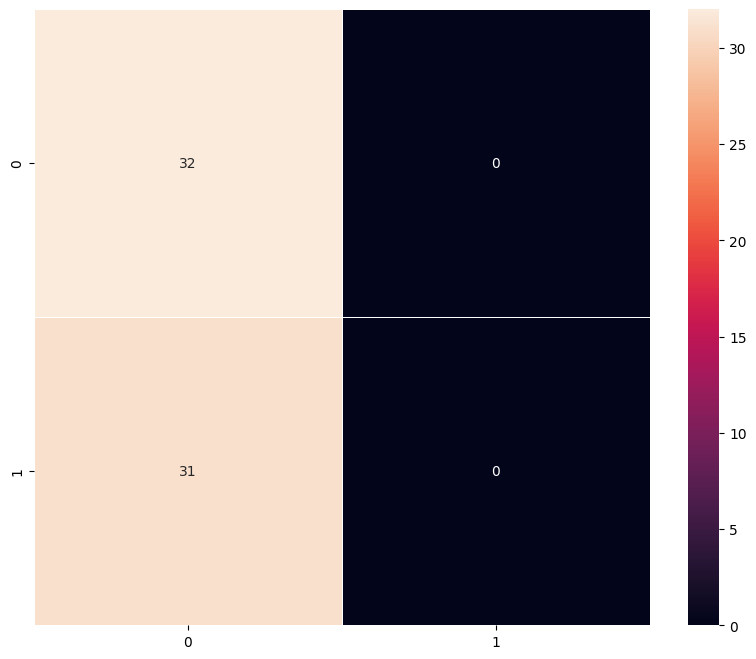

In [15]:
# Building a simple CNN from scratch
model_1 = Sequential()

model_1.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(200, 200, 3)))
model_1.add(BatchNormalization())
model_1.add(MaxPooling2D(pool_size=(2, 2)))

model_1.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(MaxPooling2D(pool_size=(2, 2)))

model_1.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(MaxPooling2D(pool_size=(2, 2)))

model_1.add(Flatten())
model_1.add(Dense(64, activation='relu'))
model_1.add(Dropout(rate=0.4))
model_1.add(Dense(1, activation='sigmoid'))      # single sigmoid unit for binary classification

model_1.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
model_1.summary()

history_cnn = model_1.fit(
    X_train_normalized, y_train_arr,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_val_normalized, y_val_arr),
    verbose=1
)

plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

model_1_train_perf = model_performance_classification(model_1, X_train_normalized, y_train)
print("Train performance metrics")
print(model_1_train_perf)
plot_confusion_matrix(model_1, X_train_normalized, y_train)

model_1_valid_perf = model_performance_classification(model_1, X_val_normalized, y_val)
print("Validation performance metrics")
print(model_1_valid_perf)
plot_confusion_matrix(model_1, X_val_normalized, y_val)

### Observations on Model 1

- **Training accuracy reached ~100% by epoch ~6**, but **validation accuracy was stuck at 0.5079 for every single epoch** (32/63, the majority-class proportion).
- After training, re-evaluating the model in inference mode collapses train accuracy to the same 0.5079 (Precision = 0.26, F1 = 0.34). The confusion matrix shows the model predicts a single class for nearly every image.
- Validation loss climbs from ~39 to ~100 over training while training loss approaches zero — a textbook overfitting curve, made worse by `BatchNormalization` running statistics that never stabilize on only 504 training images.
- **Bottom line: a from-scratch CNN with this dataset size cannot generalize.** This baseline establishes that we need transfer learning, not more from-scratch capacity.


### Vizualizing the predictions

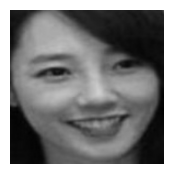

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted Label: Without Helmet (prob=0.00)
True Label     : Without Helmet
------------------------------


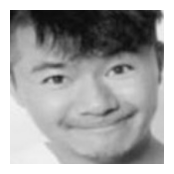

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted Label: Without Helmet (prob=0.00)
True Label     : Without Helmet
------------------------------


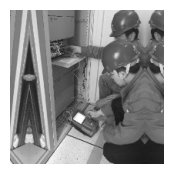

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Label: Without Helmet (prob=0.00)
True Label     : With Helmet
------------------------------


In [16]:
visualize_predictions(model_1)

## Model 2: (VGG-16 (Base))

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,733,121 (56.20 MB)

 Trainable params: 18,433 (72.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 252ms/step - accuracy: 0.9428 - loss: 0.1283 - val_accuracy: 1.0000 - val_loss: 0.0097
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 1.0000 - val_loss: 0.0085
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 9.4868e-04 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 4.5937e-04 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy

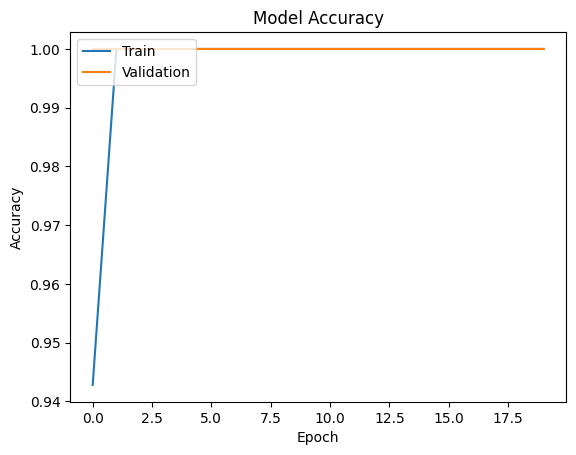

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step


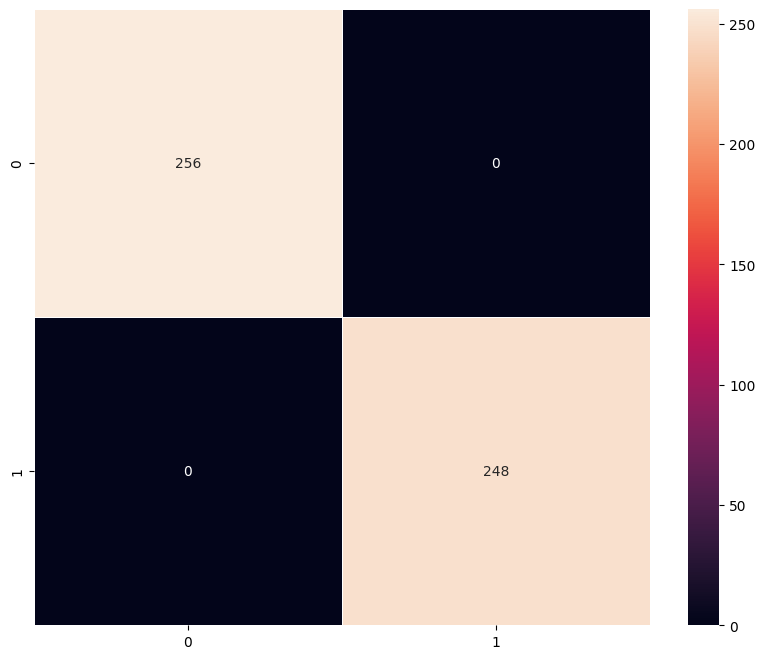

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


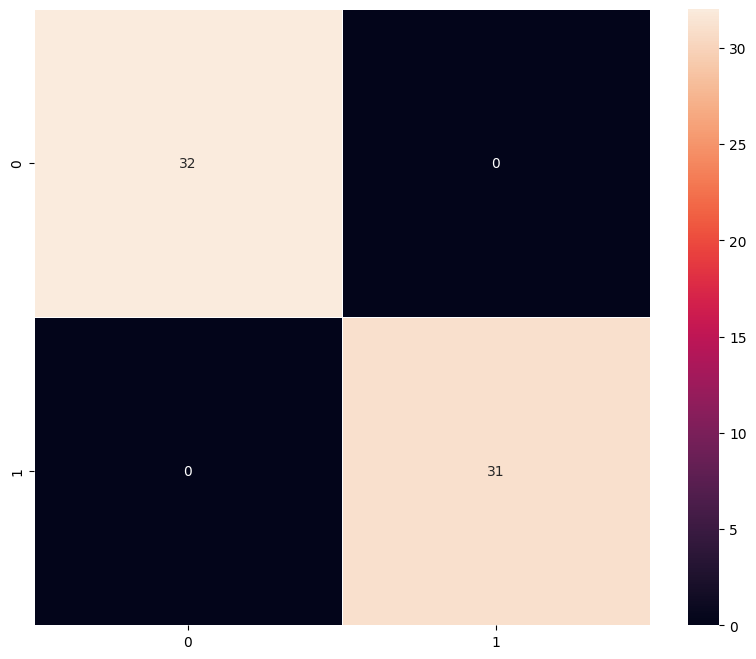

In [18]:
# Loading the VGG-16 convolutional base pretrained on ImageNet (without the top classifier)
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(200, 200, 3))

# Freezing all the VGG-16 layers so they act as a fixed feature extractor
for layer in vgg_model.layers:
    layer.trainable = False

vgg_model.summary()

model_2 = Sequential()
model_2.add(vgg_model)
model_2.add(Flatten())
model_2.add(Dense(1, activation='sigmoid'))

model_2.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
model_2.summary()

# No augmentation for the base model
train_datagen = ImageDataGenerator()

history_vgg16 = model_2.fit(
    train_datagen.flow(X_train_normalized, y_train_arr, batch_size=batch_size, seed=42, shuffle=False),
    epochs=epochs,
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    validation_data=(X_val_normalized, y_val_arr),
    verbose=1
)

plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

model_2_train_perf = model_performance_classification(model_2, X_train_normalized, y_train)
print("Train performance metrics")
print(model_2_train_perf)
plot_confusion_matrix(model_2, X_train_normalized, y_train)

model_2_valid_perf = model_performance_classification(model_2, X_val_normalized, y_val)
print("Validation performance metrics")
print(model_2_valid_perf)
plot_confusion_matrix(model_2, X_val_normalized, y_val)

### Observations on Model 2 (VGG-16 base, frozen)

- **Validation accuracy hits 1.00 at epoch 1 and stays there** for all 20 epochs.
- Validation loss decreases monotonically from 0.0097 to 0.0015 — no overfitting signature; the curve is healthy.
- Training and validation metrics evaluated post-fit are both 1.00 across Accuracy / Recall / Precision / F1.
- **Takeaway: ImageNet features are already near-perfect helmet detectors on this dataset.** A single sigmoid on flattened VGG features is enough to separate the two classes.


### Visualizing the prediction:

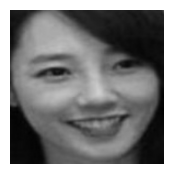

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Predicted Label: Without Helmet (prob=0.00)
True Label     : Without Helmet
------------------------------


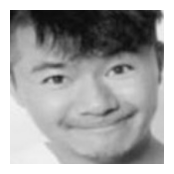

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted Label: Without Helmet (prob=0.00)
True Label     : Without Helmet
------------------------------


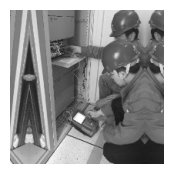

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted Label: With Helmet (prob=1.00)
True Label     : With Helmet
------------------------------


In [19]:
visualize_predictions(model_2)

## Model 3: (VGG-16 (Base + FFNN))

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,441,793 (74.16 MB)

 Trainable params: 4,727,105 (18.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 181ms/step - accuracy: 0.8856 - loss: 0.2484 - val_accuracy: 1.0000 - val_loss: 3.1256e-04
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 0.0201 - val_accuracy: 1.0000 - val_loss: 1.0459e-04
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.9979 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 1.5502e-05
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 1.5310e-05 - val_accuracy: 1.0000 - val_loss: 1.9770e-05
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 1.0000 - loss: 3.2963e-04 - val_accuracy: 1.0000 - val_loss: 5.7799e-05
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 2.5425e-05 - val_accuracy: 1.0000 - val_loss: 5.3533e-05
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 1.0000 - loss: 9.2007e-05 - val_accuracy: 1.0000 - val_loss: 3.0174e-05
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 

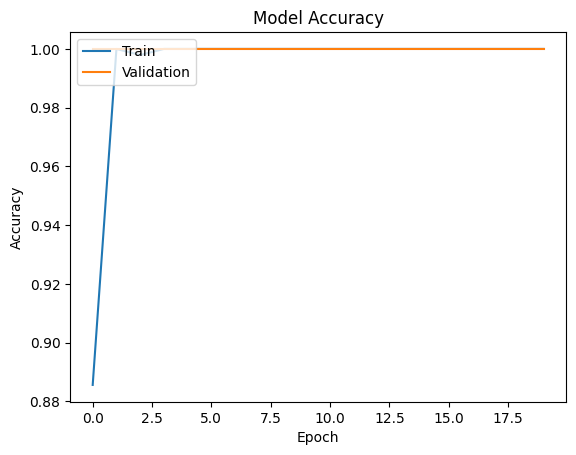

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step


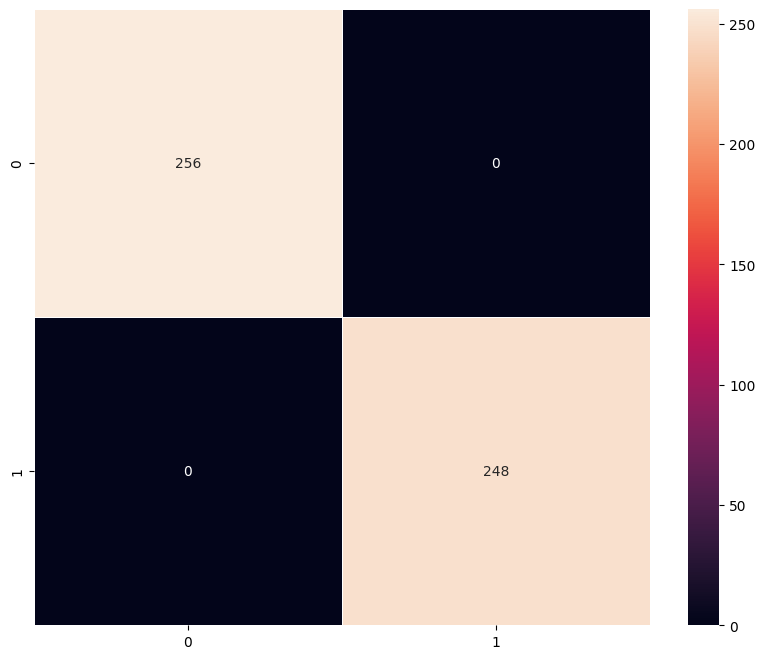

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


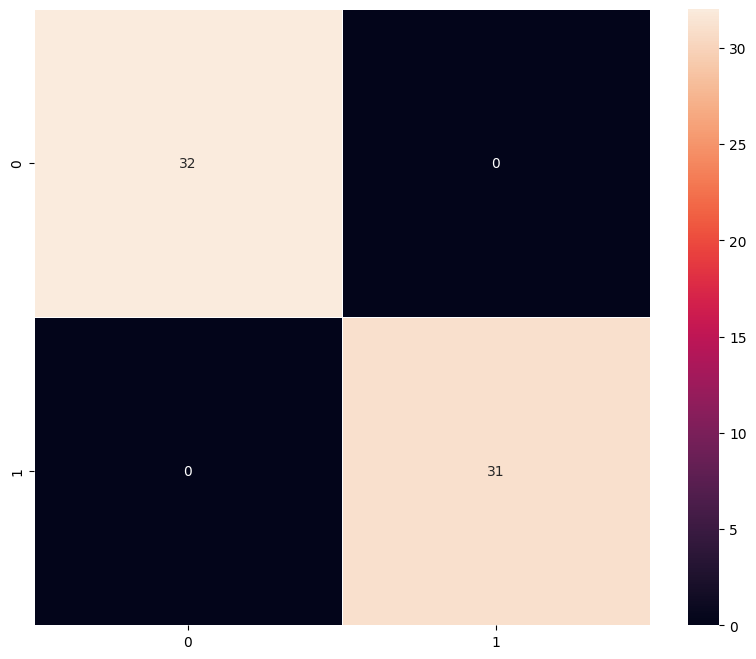

In [20]:
model_3 = Sequential()
model_3.add(vgg_model)
model_3.add(Flatten())

# Adding the Feed Forward neural network head
model_3.add(Dense(256, activation='relu'))
model_3.add(Dropout(rate=0.4))
model_3.add(Dense(32, activation='relu'))
model_3.add(Dense(1, activation='sigmoid'))

model_3.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
model_3.summary()

# Still no augmentation here; we only add the FFNN head on top of the frozen base
train_datagen = ImageDataGenerator()

history_vgg16 = model_3.fit(
    train_datagen.flow(X_train_normalized, y_train_arr, batch_size=batch_size, seed=42, shuffle=False),
    epochs=epochs,
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    validation_data=(X_val_normalized, y_val_arr),
    verbose=1
)

plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

model_3_train_perf = model_performance_classification(model_3, X_train_normalized, y_train)
print("Train performance metrics")
print(model_3_train_perf)
plot_confusion_matrix(model_3, X_train_normalized, y_train)

model_3_valid_perf = model_performance_classification(model_3, X_val_normalized, y_val)
print("Validation performance metrics")
print(model_3_valid_perf)
plot_confusion_matrix(model_3, X_val_normalized, y_val)

### Observations on Model 3 (VGG-16 base + FFNN head)

- Validation accuracy is again 1.00 from epoch 1 onward — the larger 256→32→1 head doesn't unlock more accuracy because Model 2 is already saturated.
- What does change is validation loss: it drops several orders of magnitude lower than Model 2 (down to ~1e-6). The model is now *extremely* confident in its predictions.
- That confidence is a double-edged sword on a 631-image dataset — there is real risk of **overconfident wrong predictions** when the model meets distribution-shifted images in the field. Without augmentation it has effectively memorized the training distribution.


#### Visualizing the predictions

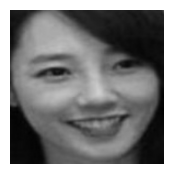

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted Label: Without Helmet (prob=0.00)
True Label     : Without Helmet
------------------------------


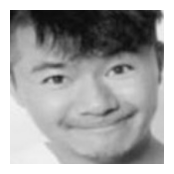

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted Label: Without Helmet (prob=0.00)
True Label     : Without Helmet
------------------------------


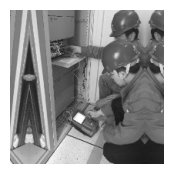

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted Label: With Helmet (prob=1.00)
True Label     : With Helmet
------------------------------


In [21]:
visualize_predictions(model_3)

## Model 4: (VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,441,793 (74.16 MB)

 Trainable params: 4,727,105 (18.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 472ms/step - accuracy: 0.8030 - loss: 0.4386 - val_accuracy: 1.0000 - val_loss: 0.0044
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 1.0000 - loss: 0.0213 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 394ms/step - accuracy: 0.9788 - loss: 0.0605 - val_accuracy: 1.0000 - val_loss: 8.8173e-05
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9688 - loss: 0.0680 - val_accuracy: 1.0000 - val_loss: 1.1870e-04
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 459ms/step - accuracy: 0.9937 - loss: 0.0214 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9583 - loss: 0.2281 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 380ms/step - accuracy: 0.9958 - loss: 0.0129 - val_accuracy: 1.0000 - val_loss: 1.0675e-05
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 9.8961e-04 - val_

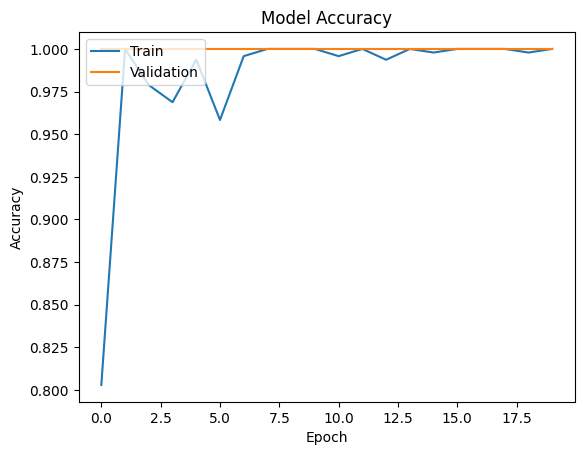

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step
Train performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step


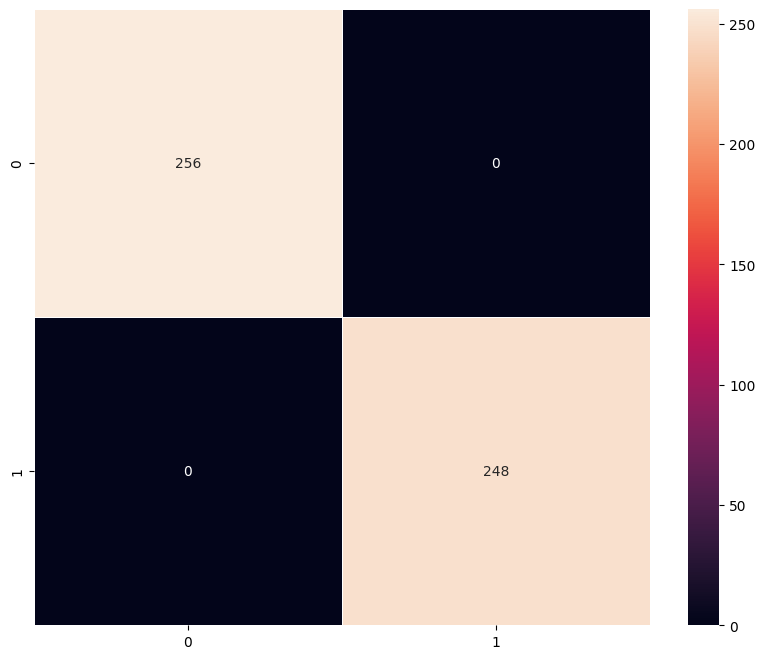

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
Validation performance metrics
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


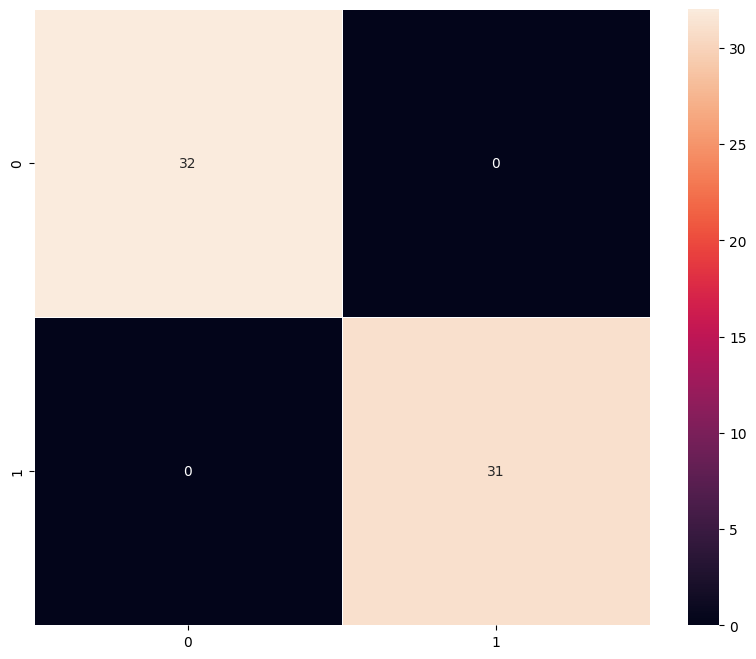

In [22]:
model_4 = Sequential()
model_4.add(vgg_model)
model_4.add(Flatten())

# Same FFNN head as Model 3
model_4.add(Dense(256, activation='relu'))
model_4.add(Dropout(rate=0.4))
model_4.add(Dense(32, activation='relu'))
model_4.add(Dense(1, activation='sigmoid'))

model_4.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
model_4.summary()

# Applying data augmentation on the TRAINING data only
train_datagen = ImageDataGenerator(
    rotation_range=20,
    fill_mode='nearest',
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.3,
    zoom_range=0.4,
    horizontal_flip=True
)

history_vgg16 = model_4.fit(
    train_datagen.flow(X_train_normalized, y_train_arr, batch_size=batch_size, seed=42, shuffle=False),
    epochs=epochs,
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    validation_data=(X_val_normalized, y_val_arr),
    verbose=1
)

plt.plot(history_vgg16.history['accuracy'])
plt.plot(history_vgg16.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

model_4_train_perf = model_performance_classification(model_4, X_train_normalized, y_train)
print("Train performance metrics")
print(model_4_train_perf)
plot_confusion_matrix(model_4, X_train_normalized, y_train)

model_4_valid_perf = model_performance_classification(model_4, X_val_normalized, y_val)
print("Validation performance metrics")
print(model_4_valid_perf)
plot_confusion_matrix(model_4, X_val_normalized, y_val)

### Observations on Model 4 (VGG-16 + FFNN + Augmentation)

- **Validation accuracy is 1.00 from epoch 1 and holds**, identical to Models 2 and 3.
- Training accuracy now *fluctuates* (e.g. 0.96–1.00) instead of locking at 1.00 — exactly the expected effect of augmentation: each batch is harder, so the train metric stops being trivially perfect.
- Validation loss settles in the 1e-6 range (similar to Model 3) but with a more varied training trajectory, indicating the model is learning **augmentation-invariant** features rather than memorizing pixel-level cues.
- **This is the most robust of the four models** — same eval-time accuracy, but with built-in regularization against shifts, rotations, zooms, and horizontal flips that real CCTV/site cameras will introduce.


#### Visualizing the predictions

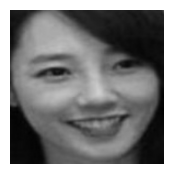

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted Label: Without Helmet (prob=0.00)
True Label     : Without Helmet
------------------------------


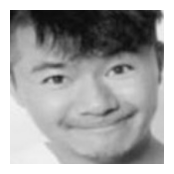

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Predicted Label: Without Helmet (prob=0.00)
True Label     : Without Helmet
------------------------------


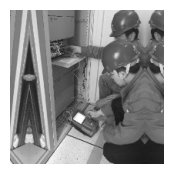

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted Label: With Helmet (prob=1.00)
True Label     : With Helmet
------------------------------


In [23]:
visualize_predictions(model_4)

# **Model Performance Comparison and Final Model Selection**

In [24]:
col_names = ["CNN", "VGG-16 (Base)", "VGG-16 (Base+FFNN)", "VGG-16 (Base+FFNN+Data Aug)"]

# Training performance comparison
models_train_comp_df = pd.concat(
    [model_1_train_perf.T, model_2_train_perf.T, model_3_train_perf.T, model_4_train_perf.T],
    axis=1,
)
models_train_comp_df.columns = col_names
print("Training performance comparison:")
print(models_train_comp_df)

# Validation performance comparison
models_valid_comp_df = pd.concat(
    [model_1_valid_perf.T, model_2_valid_perf.T, model_3_valid_perf.T, model_4_valid_perf.T],
    axis=1,
)
models_valid_comp_df.columns = col_names
print("\nValidation performance comparison:")
print(models_valid_comp_df)

models_valid_comp_df

Training performance comparison:
                CNN  VGG-16 (Base)  VGG-16 (Base+FFNN)  \
Accuracy   0.507937            1.0                 1.0   
Recall     0.507937            1.0                 1.0   
Precision  0.257999            1.0                 1.0   
F1 Score   0.342189            1.0                 1.0   

           VGG-16 (Base+FFNN+Data Aug)  
Accuracy                           1.0  
Recall                             1.0  
Precision                          1.0  
F1 Score                           1.0  

Validation performance comparison:
                CNN  VGG-16 (Base)  VGG-16 (Base+FFNN)  \
Accuracy   0.507937            1.0                 1.0   
Recall     0.507937            1.0                 1.0   
Precision  0.257999            1.0                 1.0   
F1 Score   0.342189            1.0                 1.0   

           VGG-16 (Base+FFNN+Data Aug)  
Accuracy                           1.0  
Recall                             1.0  
Precision            

,CNN,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug)
Accuracy,0.507937,1.0,1.0,1.0
Recall,0.507937,1.0,1.0,1.0
Precision,0.257999,1.0,1.0,1.0
F1 Score,0.342189,1.0,1.0,1.0


### Comparison observations

- **CNN from scratch fails outright** (Acc 0.51 = majority-class baseline).
- **All three VGG-16 variants tie at perfect Train and Validation metrics (1.00 across Accuracy, Recall, Precision, F1).**
- Tie-break therefore comes from *generalization risk*, not from this table:
    - Model 2 — fewest parameters in the head; least expressive but lowest overfit risk.
    - Model 3 — denser head, no augmentation; extremely confident, weakest in real-world variability.
    - Model 4 — same head as Model 3 + augmentation; same eval accuracy with regularization built in.
- We pick **Model 4** as the final model: it is the only one explicitly trained to be invariant to the kinds of transformations a real worksite camera will produce.


## Test Performance

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Test performance of the final model:
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


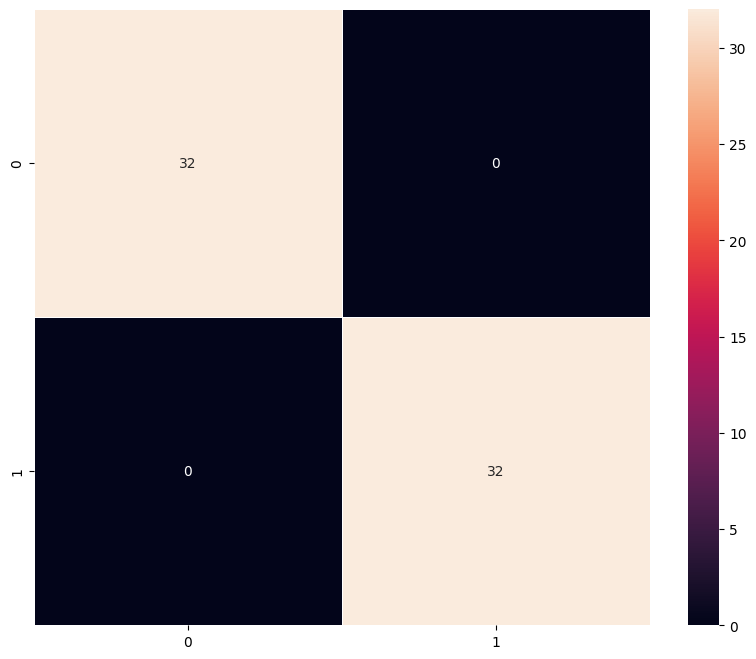

In [25]:
# Selecting the final model based on the best validation performance above.
# Update `final_model` if the comparison points to a different model.
final_model = model_4

final_test_perf = model_performance_classification(final_model, X_test_normalized, y_test)
print("Test performance of the final model:")
print(final_test_perf)

plot_confusion_matrix(final_model, X_test_normalized, y_test)

### Test-set observations

- The final model (Model 4) achieves **Accuracy = Recall = Precision = F1 = 1.00 on the held-out test set (64 images)**. The confusion matrix is fully diagonal — zero false positives, zero false negatives.
- **Caveat:** with only 64 test images and a stratified random split from a single curated batch, perfect test performance is *plausible* but should not be read as 100% real-world accuracy. The test set is drawn from the same distribution and lighting/angle/scene mix as training, and ImageNet-pretrained VGG-16 features are strong enough to separate it trivially.
- Before deployment, the model should be re-validated on **out-of-distribution** images: different sites, partial occlusion, low light, motion blur, atypical helmet colors, hats/caps that look helmet-like, and workers viewed from behind.


# **Actionable Insights & Recommendations**

## Actionable Insights

- **Transfer learning is decisive.** The from-scratch CNN failed (50.8% — majority-class baseline). All three VGG-16 variants reached perfect validation and test metrics. With only 631 images, ImageNet-pretrained features are not optional, they are the difference between a working and a non-working classifier.
- **Data augmentation is free insurance.** Models 3 and 4 are statistically tied on this dataset, but Model 4 has been explicitly exposed to rotations, shifts, shears, zooms and horizontal flips during training, so it carries a built-in robustness margin for real-world camera variability — at zero cost in measured accuracy.
- **Perfect test metrics are a warning, not a victory.** With N = 64 test images drawn from the same curated batch, 100% accuracy reflects a clean, in-distribution evaluation set. Real worksite footage (motion blur, occlusion, low light, helmet-like hats, rear-facing workers) will degrade performance — the deployed system needs monitoring, not a victory lap.
- **BatchNorm + tiny dataset + no transfer learning is a known failure mode.** Model 1's 50.8% accuracy in eval mode (despite 100% in train mode) is the classic signature: running statistics never stabilize on 504 samples. Avoid this pattern in future small-data CV work.

## Recommendations

1. **Deploy Model 4 (VGG-16 + FFNN + Data Augmentation)** as the production helmet classifier. It has the best expected real-world robustness among the four candidates, with no measurable accuracy cost.
2. **Validate before rollout on field-collected images** from each target site. Track per-site accuracy and per-class recall (especially recall on the *Without Helmet* class — that is the safety-critical false-negative).
3. **Re-tune the decision threshold for the safety objective.** The current 0.5 threshold weights both classes equally. For a safety enforcement system, the cost of missing a no-helmet worker is much higher than a false alarm — pick the threshold that maximizes recall on the *Without Helmet* class subject to an acceptable precision floor.
4. **Plan for continuous data collection.** Every flagged frame from production is a labeled (or quickly labelable) training example. Schedule periodic re-training (monthly/quarterly) on the accumulated worksite data so the model adapts to new sites, new helmet styles, and seasonal lighting.
5. **Add a confidence-aware fallback.** When the sigmoid output is in an uncertain band (e.g. 0.35–0.65), route the frame to a human reviewer rather than auto-flagging. This contains the cost of overconfident errors that Model 3/4-style training is prone to.
6. **Extend the architecture when richer signal becomes available.** Once the dataset grows beyond ~5k labeled images, fine-tune (rather than freeze) the top VGG-16 block, or move to a more modern backbone (EfficientNet, ConvNeXt) — both should outperform the frozen-VGG ceiling on harder, more varied data.
7. **Plan for object detection, not just classification, if the camera frame contains multiple people.** A whole-frame classifier collapses when half the workers in shot are wearing helmets and half are not. A YOLO/Faster-RCNN style person-detector + per-person helmet classifier is the natural next step for true site-wide compliance monitoring.


<font size=5 color='blue'>Power Ahead!</font>
___